In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_PATH = "smartvision_dataset/classification/train"
VAL_PATH = "smartvision_dataset/classification/val"

train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

2026-04-18 20:10:06.434767: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-18 20:10:06.434811: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-18 20:10:06.434836: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-18 20:10:06.434882: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-18 20:10:06.434904: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [6]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15


2026-04-18 20:10:17.203682: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-18 20:10:17.314400: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


55/55 [==============================] - 26s 349ms/step - loss: 3.2290 - accuracy: 0.1091 - val_loss: 3.5090 - val_accuracy: 0.0640
Epoch 2/15
55/55 [==============================] - 17s 318ms/step - loss: 2.6123 - accuracy: 0.2617 - val_loss: 3.3814 - val_accuracy: 0.0613
Epoch 3/15
55/55 [==============================] - 18s 322ms/step - loss: 2.1363 - accuracy: 0.4126 - val_loss: 3.3095 - val_accuracy: 0.0507
Epoch 4/15
55/55 [==============================] - 18s 321ms/step - loss: 1.7670 - accuracy: 0.5120 - val_loss: 3.2132 - val_accuracy: 0.0667
Epoch 5/15
55/55 [==============================] - 18s 334ms/step - loss: 1.4896 - accuracy: 0.5874 - val_loss: 2.9402 - val_accuracy: 0.1440
Epoch 6/15
55/55 [==============================] - 19s 340ms/step - loss: 1.2382 - accuracy: 0.6566 - val_loss: 2.3468 - val_accuracy: 0.3787
Epoch 7/15
55/55 [==============================] - 26s 478ms/step - loss: 0.9947 - accuracy: 0.7263 - val_loss: 2.0820 - val_accuracy: 0.4613
Epoch 8/15

In [11]:
model.save("models/resnet50_model.h5")
print("ResNet Model Saved ✅")

/Users/sabari/Documents/DS/GUVI/SmartVision-AI/venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


ResNet Model Saved ✅


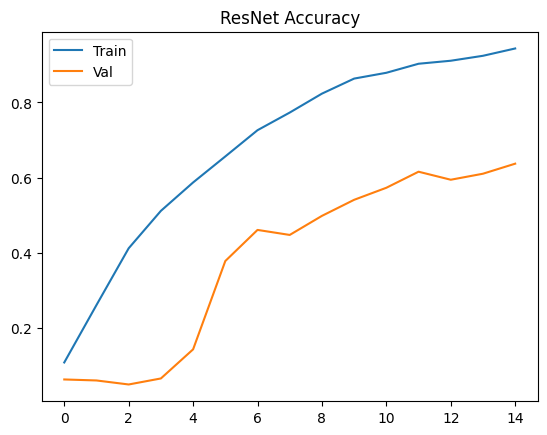

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("ResNet Accuracy")
plt.legend(["Train","Val"])
plt.show()